<a href="https://colab.research.google.com/github/Ashim-codes/MachineLearning-lab/blob/main/lab4/Linear%20Regression%20and%20Regulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [5]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.head()
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [6]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


model=LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)


mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [7]:
ridge = Ridge (alpha = 1.0)
ridge.fit(X_train_scaled,y_train)
ridge_pred = ridge.predict(X_test_scaled)

In [8]:
lasso=Lasso(alpha=0.1)
lasso.fit(X_train_scaled,y_train)
lasso_pred=lasso.predict(X_test_scaled)

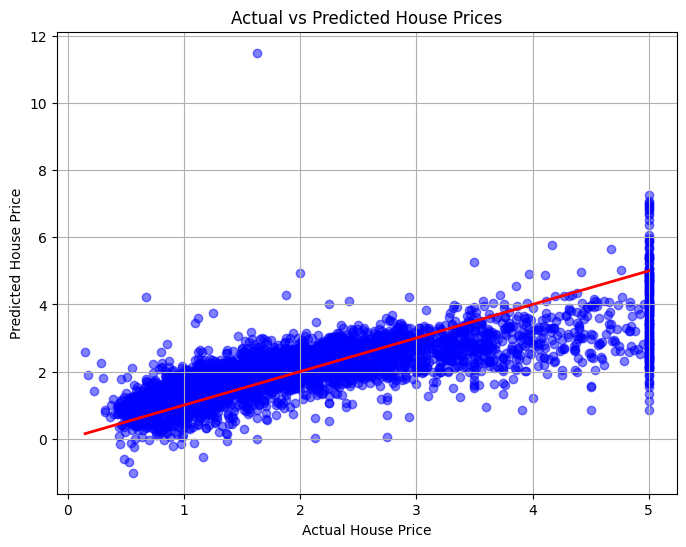

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,color='blue',alpha=0.5)
# Ideal prediction line
plt.plot([y_test.min(), y_test.max()],[y_test.min(),
y_test.max()], color='red', linewidth=2)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

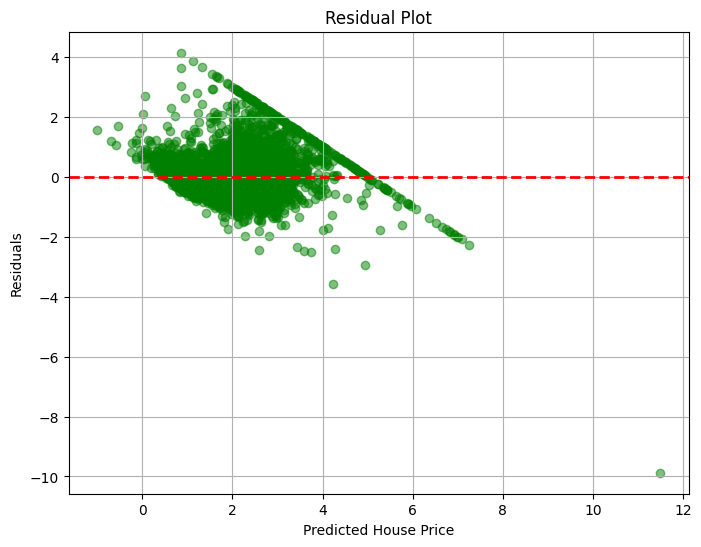

In [10]:
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, color='green', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()



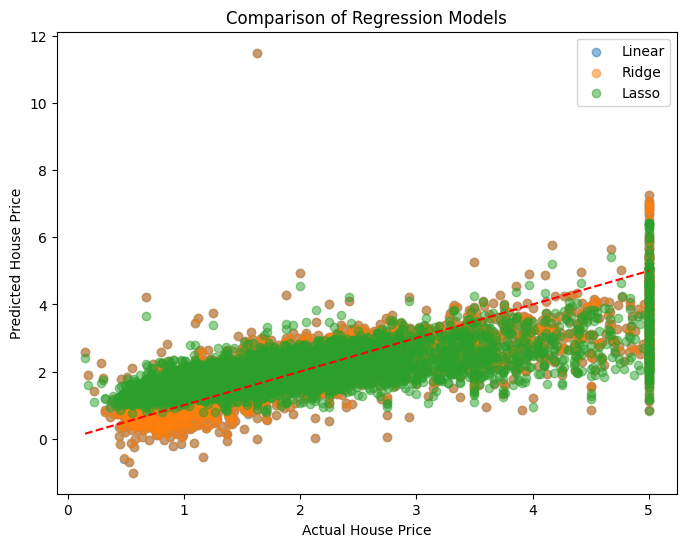

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, label="Linear")

# Define and fit Lasso model for prediction within this cell
lasso=Lasso(alpha=0.1)
lasso.fit(X_train_scaled,y_train)
lasso_pred=lasso.predict(X_test_scaled)

plt.scatter(y_test, ridge_pred, alpha=0.5, label="Ridge")
plt.scatter(y_test, lasso_pred, alpha=0.5, label="Lasso")
plt.plot([y_test.min(), y_test.max()], [y_test.min(),
y_test.max()], 'r--')
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Comparison of Regression Models")
plt.legend()
plt.show()
